# Potato Leaf Disease Classification Using CNN

### Import Libraries

In [38]:
import tensorflow
import cv2
import numpy
import pandas
import matplotlib
import sklearn

print("All libraries installed successfully!")

All libraries installed successfully!


### Load Dataset

In [39]:
import os

print(os.listdir("Dataset"))

['PlantVillage', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight']


In [40]:
data_dir = "Dataset"

categories = [
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy"
]

print(categories)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


### Preprocess Images

In [41]:
import cv2
import numpy as np

data = []
labels = []

img_size = 128

for category in categories:

    folder_path = os.path.join(data_dir, category)

    label = categories.index(category)

    for img in os.listdir(folder_path):

        img_path = os.path.join(folder_path, img)

        try:
            image = cv2.imread(img_path)

            image = cv2.resize(image, (img_size, img_size))

            data.append(image)
            labels.append(label)

        except Exception as e:
            print("Error loading image:", img_path)

In [42]:
X = np.array(data)
y = np.array(labels)

print("Image data shape:", X.shape)
print("Labels shape:", y.shape)

Image data shape: (1721, 128, 128, 3)
Labels shape: (1721,)


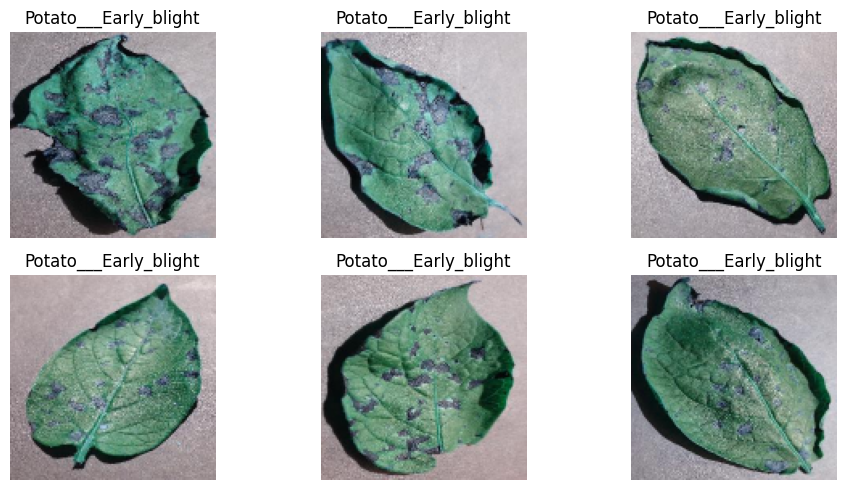

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(X[i])

    plt.title(categories[y[i]])

    plt.axis("off")

plt.tight_layout()
plt.show()

### Normalize Data

In [44]:
X = X / 255.0

print("Normalization completed")

Normalization completed


In [45]:
from tensorflow.keras.utils import to_categorical

y = to_categorical(y)

print("Updated label shape:", y.shape)

Updated label shape: (1721, 3)


In [46]:
[1,0,0]
[0,1,0]
[0,0,1]

[0, 0, 1]

### Train Test Split

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1376, 128, 128, 3)
Testing data: (345, 128, 128, 3)


### Build CNN Model

In [48]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential()

# Input Layer
model.add(Input(shape=(128,128,3)))

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Third Convolution Layer
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(3, activation='softmax'))

### Compile Model

In [49]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [50]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

### Train Model

In [51]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=32
)

Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 13s 263ms/step - accuracy: 0.5661 - loss: 0.8741 - val_accuracy: 0.7449 - val_loss: 0.6105
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 12s 269ms/step - accuracy: 0.8190 - loss: 0.5209 - val_accuracy: 0.8725 - val_loss: 0.3673
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 13s 299ms/step - accuracy: 0.8648 - loss: 0.3633 - val_accuracy: 0.8609 - val_loss: 0.3297
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 235ms/step - accuracy: 0.8808 - loss: 0.3126 - val_accuracy: 0.8435 - val_loss: 0.3579
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 242ms/step - accuracy: 0.8714 - loss: 0.3187 - val_accuracy: 0.8638 - val_loss: 0.2908
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 12s 281ms/step - accuracy: 0.9150 - loss: 0.2182 - val_accuracy: 0.9826 - val_loss: 0.0913
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 9s 216ms/step - accuracy: 0.9491 - loss: 0.1324 - val_accuracy: 0.9681 - val_loss: 0.0917
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 259ms/step - accuracy: 0.9440 - loss: 0.1449 - val_accur

In [52]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.9768 - loss: 0.0825
Test Accuracy: 0.9768115878105164


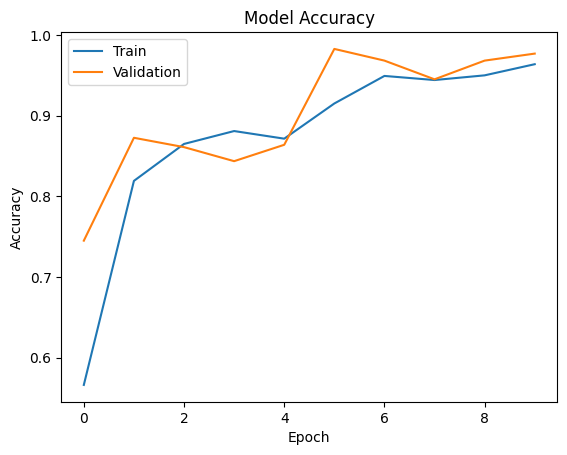

In [53]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

### Evaluate Model

In [54]:
model.save("potato_disease_model.h5")

print("Model saved successfully")

Model saved successfully


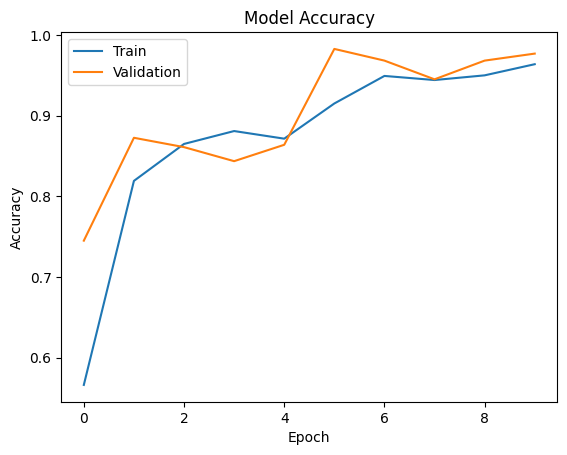

In [55]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

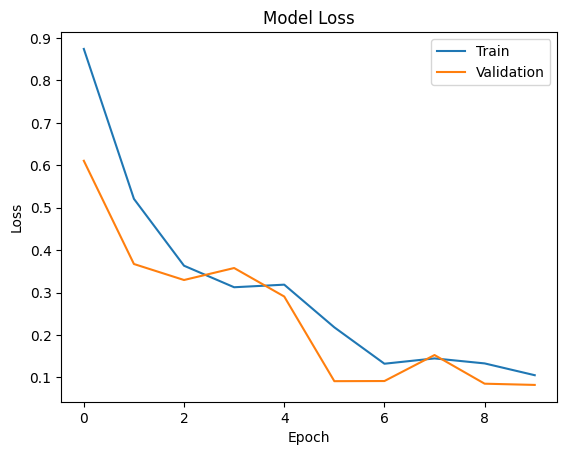

In [56]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

### Prediction System

In [57]:
def predict_and_show(image_path):

    image = cv2.imread(image_path)

    image_resized = cv2.resize(image, (128,128))

    image_normalized = image_resized / 255.0

    image_reshaped = np.reshape(image_normalized, (1,128,128,3))

    prediction = model.predict(image_reshaped)

    class_index = np.argmax(prediction)

    predicted_label = categories[class_index]

    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(f"Prediction: {predicted_label}")
    plt.axis("off")

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


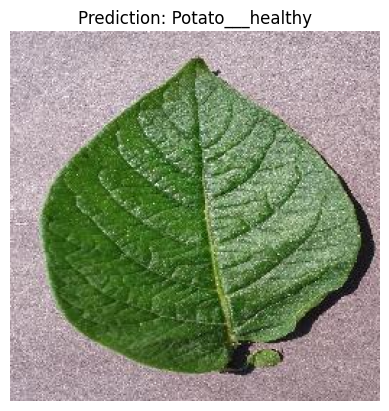

In [58]:
predict_and_show("Dataset/Potato___healthy/31a09d39-6791-4ecb-8f44-af2ed85dbd33___RS_HL 1970.JPG")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


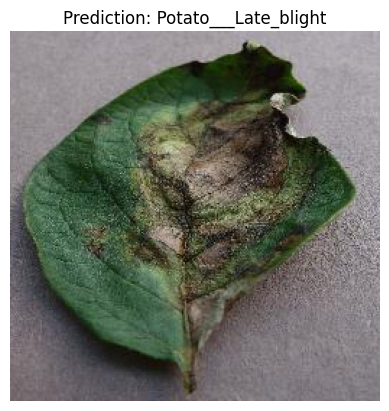

In [59]:
predict_and_show("Dataset/Potato___Late_blight/0c2628d4-8d64-48a9-a157-19a9c902e304___RS_LB 4590.jpg")

In [60]:
model.save("potato_disease_model.keras")

### Load Model

In [61]:
# from tensorflow.keras.models import load_model

# loaded_model = load_model("potato_disease_model.keras")

# print("Model loaded successfully!")

## Conclusion

This project uses a Convolutional Neural Network (CNN) to classify potato leaf diseases into Early Blight, Late Blight, and Healthy categories. The model achieved approximately 96% accuracy using the PlantVillage dataset.